# Use timegan generated wti only

In [13]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import gc
import tensorflow as tf
from tensorflow.keras import backend as K
import my_lstm
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast

In [14]:
df = pd.read_csv('../data/timegan_outputs/timegan_stitched_with_real.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1958-02-01,0.024847,-0.015705,0.027807,-0.027773,-0.000809,0.185145,0.006441,0.000379,0.019757
1,1958-03-01,0.027390,-0.022099,0.024366,-0.029438,0.003339,0.215476,0.009997,0.003410,0.114539
2,1958-04-01,0.004842,-0.011170,0.019614,-0.000271,0.002325,0.159208,-0.003944,-0.001126,0.101262
3,1958-05-01,-0.016618,-0.006536,-0.012564,0.000679,-0.000740,0.254986,-0.008159,-0.004714,0.055544
4,1958-06-01,-0.002823,-0.000563,-0.024216,0.003817,0.002150,0.169251,0.000508,-0.001069,0.086817


In [15]:
feature_cols = [
    "wti_ret"
]

target_col = "wti_ret"

In [16]:
df = df.sort_values("Date").reset_index(drop=True)

# compute indices based on original evaluation and test split
train_size = df.index[df["Date"] < "2014-02-01"][-1] + 1
val_end = df.index[df["Date"] <= "2020-01-01"][-1] + 1

# split using iloc 
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 672
Validation data length: 72
Test data length: 72


In [5]:
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
}

param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []
failed_combos = []

max_retries = 2

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    success = False

    for attempt in range(1, max_retries + 1):
        try:
            print(f"Attempt {attempt}/{max_retries}")

            # clear memory before each attempt
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

            val_forecasts = expanding_window_lstm_forecast(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            initial_train_size=train_size,
            end_idx=val_end,
            date_col="Date",
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
            )

            if len(val_forecasts) == 0:
                print("No forecasts generated.")
                raise ValueError("No forecasts generated")

            mse = mean_squared_error(
                val_forecasts["actual"],
                val_forecasts["predicted"]
            )

            print(f"Validation MSE: {mse:.6f}")

            results_grid.append({
                "lookback": lb,
                "dropout": dr,
                "units": units,
                "epochs": ep,
                "mse": mse,
                "attempt_used": attempt
            })

            success = True
            break

        except Exception as e:
            print(f"Error on attempt {attempt}: {e}")

            # clear memory after failure 
            K.clear_session()
            tf.keras.backend.clear_session()
            gc.collect()

    if not success:
        print("Failed after all retries. Skipping this combination.")
        failed_combos.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep
        })

# --------------------------------------------------
# results
# --------------------------------------------------

results_grid_df = pd.DataFrame(results_grid).sort_values("mse").reset_index(drop=True)
failed_combos_df = pd.DataFrame(failed_combos)


[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50
Attempt 1/2


2026-03-30 17:06:38.197676: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Error on attempt 1: Graph execution error:

Detected at node 'mul_12' defined at (most recent call last):
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/tornado/platform/asyncio.py", line 205, in start
      self.asyncio_loop

2026-03-30 17:27:40.055650: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at resource_variable_ops.cc:611 : INVALID_ARGUMENT: Cannot update variable with shape [1] using a Tensor with shape [0], shapes must be equal.


Error on attempt 1: Graph execution error:

Detected at node 'AssignSubVariableOp_7' defined at (most recent call last):
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/tornado/platform/asyncio.py", line 205, in start
      se

In [9]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.04686545558950857,
  'attempt_used': 2},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.03853399373755948,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.038427896666145565,
  'attempt_used': 2},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.04126808884677222,
  'attempt_used': 2},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.04126808884677222,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.03911792063363409,
  'attempt_used': 1},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.03911792063363409,
  'attempt_used': 1},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.0928326046844454,
  'attempt_used': 2},
 {'lookback': 10,
  'dropout': 0.001,
  

In [10]:
print("\nTop results:")
print(results_grid_df.head())

print("\nFailed combinations:")
print(failed_combos_df)


Top results:
   lookback  dropout  units  epochs       mse  attempt_used
0         2    0.001    170     100  0.038428             2
1         2    0.001    170      50  0.038534             1
2         2    0.100    170      50  0.039118             1
3         2    0.100    170     100  0.039118             1
4         2    0.100     50      50  0.041268             2

Failed combinations:
   lookback  dropout  units  epochs
0         2    0.001     50     100


In [11]:
best_params = results_grid_df.iloc[0]
best_lb = int(best_params["lookback"])
best_dr = float(best_params["dropout"])
best_units = int(best_params["units"])
best_ep = int(best_params["epochs"])

best_params

lookback          2.000000
dropout           0.001000
units           170.000000
epochs          100.000000
mse               0.038428
attempt_used      2.000000
Name: 0, dtype: float64

In [17]:
# best parameters from validation
#best_params = {}
#best_params["lookback"] = 2.0
#best_params["dropout"] = 0.001
#best_params["units"] = 170.0
#best_params["epochs"] = 100.0

# comment out if already tuned and just want to run test evaluation with best params



test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,  
    end_idx=len(df),    
    date_col="Date",        
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


Test MSE: 0.3039091630745243
Test MAPE: 3.8856689458630833
Test R²: -15.03910413761577


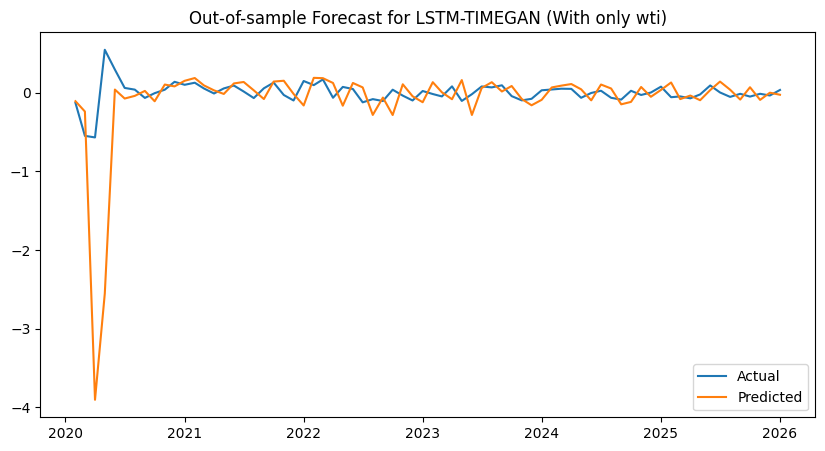

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM-TIMEGAN (With only wti)")
plt.show()

In [15]:
# save results to csv
test_results.to_csv('results/lstm_test_timegan_results.csv', index = False)